display(HTML("""
<div style="
background:linear-gradient(90deg,#1E3A8A,#2563EB);
padding:22px;
border-radius:16px;
color:white;
box-shadow:0 8px 20px rgba(0,0,0,0.18);
">

<h1 style="margin:0;">
📊 Appendix C – Evaluation Notebook
</h1>

<h3 style="margin-top:8px;font-weight:400;">
Autonomous Repository Code Reviewer
</h3>

<p style="font-size:16px;">
Reproducible evaluation across five GitHub repositories.
</p>

</div>
"""))


### 📖 Overview

This notebook presents the experimental evaluation of the proposed **AI-Powered Repository Code Reviewer**.

The system combines **Retrieval-Augmented Generation (RAG)** with a **multi-agent analysis pipeline** to automatically understand software repositories, reconstruct their architecture, analyze execution workflows, identify potential bugs, evaluate security concerns, and generate engineering recommendations.

Five open-source repositories from different software domains were evaluated. The results presented in this notebook correspond to the quantitative metrics reported in **Section 9** of the dissertation.

---

> **Evaluation Objective**

- 📂 Evaluate repository understanding quality
- 🔍 Measure semantic retrieval effectiveness
- 🏗️ Assess architecture reconstruction accuracy
- ⚙️ Evaluate execution workflow reconstruction
- 🔒 Assess security analysis quality
- 🐞 Evaluate bug detection capability
- ⭐ Measure best-practice identification
- 💡 Assess recommendation quality

---

### 📊 Evaluation Scale

All evaluation metrics are reported on a **5-point scale**.

| Rating | Meaning |
|:------:|---------|
| ⭐⭐⭐⭐⭐ | Excellent |
| ⭐⭐⭐⭐☆ | Very Good |
| ⭐⭐⭐☆☆ | Good |
| ⭐⭐☆☆☆ | Fair |
| ⭐☆☆☆☆ | Poor |

---

## 📋 Repository Evaluation Results

The table below summarizes the evaluation scores assigned to each repository after manual verification of the AI-generated analysis reports.

Each metric is evaluated on a **5-point scale**, where higher scores indicate better performance.

---

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titleweight"] = "bold"

evaluation_data = {
    "Repository": [
        "University ERP System",
        "Simple Multithreader",
        "Forest Spirit Cat Quiz",
        "Daily Mood Journal",
        "Angry Birds Game"
    ],

    "Overview":[5.0,5.0,5.0,4.6,5.0],
    "Retrieval":[5.0,5.0,5.0,5.0,5.0],
    "Understanding":[5.0,5.0,5.0,5.0,5.0],
    "Workflow":[4.9,4.8,4.9,5.0,5.0],
    "Architecture":[5.0,4.8,5.0,5.0,5.0],
    "Security":[5.0,5.0,5.0,3.8,5.0],
    "Bug Detection":[5.0,4.2,4.8,5.0,4.8],
    "Best Practices":[5.0,5.0,5.0,5.0,5.0],
    "Recommendations":[4.9,4.7,4.8,5.0,5.0],
    "Overall":[5.0,4.8,4.9,4.8,5.0],
    "Time (s)":[72,50,44,46,55]
}

df = pd.DataFrame(evaluation_data)

df

,Repository,Overview,Retrieval,Understanding,Workflow,Architecture,Security,Bug Detection,Best Practices,Recommendations,Overall,Time (s)
0,University ERP System,5.0,5.0,5.0,4.9,5.0,5.0,5.0,5.0,4.9,5.0,72
1,Simple Multithreader,5.0,5.0,5.0,4.8,4.8,5.0,4.2,5.0,4.7,4.8,50
2,Forest Spirit Cat Quiz,5.0,5.0,5.0,4.9,5.0,5.0,4.8,5.0,4.8,4.9,44
3,Daily Mood Journal,4.6,5.0,5.0,5.0,5.0,3.8,5.0,5.0,5.0,4.8,46
4,Angry Birds Game,5.0,5.0,5.0,5.0,5.0,5.0,4.8,5.0,5.0,5.0,55


In [78]:
styled = (
    df.style
    .hide(axis="index")

    # Format ONLY numeric columns
    .format({
        "Overview": "{:.1f}",
        "Retrieval": "{:.1f}",
        "Understanding": "{:.1f}",
        "Workflow": "{:.1f}",
        "Architecture": "{:.1f}",
        "Security": "{:.1f}",
        "Bug Detection": "{:.1f}",
        "Best Practices": "{:.1f}",
        "Recommendations": "{:.1f}",
        "Overall": "{:.1f}",
        "Time (s)": "{:.0f}"
    })

    .set_properties(**{
        "background-color": "#F8FBFF",
        "text-align": "center",
        "border": "1px solid #D6E4F0",
        "padding": "8px"
    })

    .set_properties(
        subset=["Overall"],
        **{
            "background-color": "#DCEEFF",
            "font-weight": "bold",
            "color": "#0D47A1"
        }
    )

    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1565C0"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "8px")
            ]
        }
    ])
)

styled


Repository,Overview,Retrieval,Understanding,Workflow,Architecture,Security,Bug Detection,Best Practices,Recommendations,Overall,Time (s)
University ERP System,5.0,5.0,5.0,4.9,5.0,5.0,5.0,5.0,4.9,5.0,72
Simple Multithreader,5.0,5.0,5.0,4.8,4.8,5.0,4.2,5.0,4.7,4.8,50
Forest Spirit Cat Quiz,5.0,5.0,5.0,4.9,5.0,5.0,4.8,5.0,4.8,4.9,44
Daily Mood Journal,4.6,5.0,5.0,5.0,5.0,3.8,5.0,5.0,5.0,4.8,46
Angry Birds Game,5.0,5.0,5.0,5.0,5.0,5.0,4.8,5.0,5.0,5.0,55


## 📊 Average Evaluation Scores

The average score for each evaluation criterion is computed across all five repositories. These values provide an overall measure of the proposed AI-powered Repository Code Reviewer's performance.

In [79]:
# Calculate average scores

avg_scores = (
    df.drop(columns=["Repository", "Time (s)"])
      .mean()
      .round(2)
)

avg_df = pd.DataFrame({
    "Criterion": avg_scores.index,
    "Average Score": avg_scores.values
})

avg_df

,Criterion,Average Score
0,Overview,4.92
1,Retrieval,5.00
2,Understanding,5.00
3,Workflow,4.92
4,Architecture,4.96
5,Security,4.76
6,Bug Detection,4.76
7,Best Practices,5.00
8,Recommendations,4.88
9,Overall,4.90


In [80]:
avg_df.style.hide(axis="index")\
.format({"Average Score":"{:.2f}"})\
.set_properties(**{
    "background-color":"#F8FBFF",
    "text-align":"center",
    "border":"1px solid #D6E4F0",
    "padding":"8px"
})\
.set_table_styles([
{
    "selector":"th",
    "props":[
        ("background-color","#1565C0"),
        ("color","white"),
        ("font-weight","bold"),
        ("padding","8px"),
        ("text-align","center")
    ]
}
])

Criterion,Average Score
Overview,4.92
Retrieval,5.00
Understanding,5.00
Workflow,4.92
Architecture,4.96
Security,4.76
Bug Detection,4.76
Best Practices,5.00
Recommendations,4.88
Overall,4.90


## 📈 Average Evaluation Scores by Criterion

The figure below visualizes the average score achieved for each evaluation criterion across all evaluated repositories.

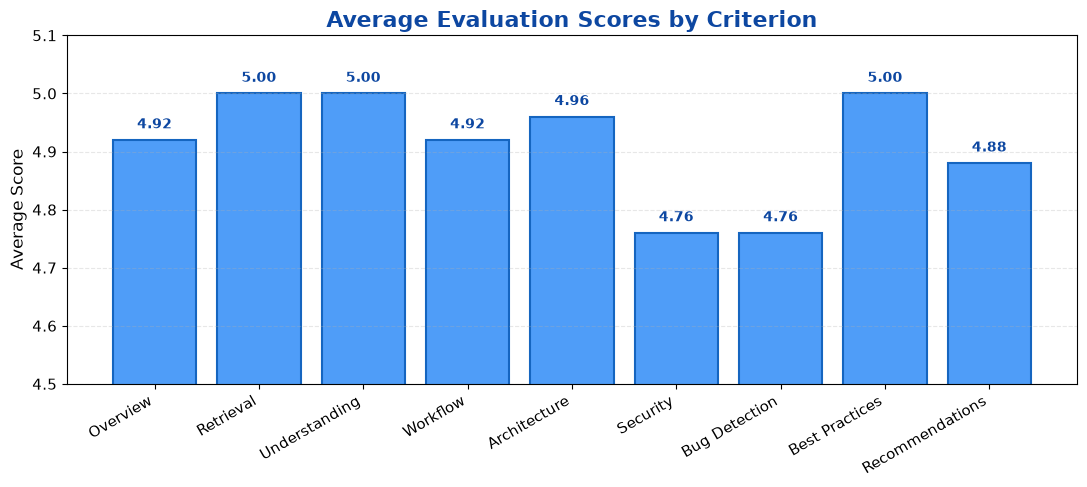

In [81]:
import matplotlib.pyplot as plt

# Remove the Overall score from the chart
plot_data = avg_df[avg_df["Criterion"] != "Overall"]

plt.figure(figsize=(11,5))

bars = plt.bar(
    plot_data["Criterion"],
    plot_data["Average Score"],
    color="#4F9DF8",
    edgecolor="#1565C0",
    linewidth=1.5
)

plt.ylim(4.5, 5.1)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.title(
    "Average Evaluation Scores by Criterion",
    fontsize=16,
    fontweight="bold",
    color="#0D47A1"
)

plt.ylabel("Average Score", fontsize=12)

plt.xticks(rotation=30, ha="right")

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="#0D47A1"
    )

plt.tight_layout()
plt.show()

## 🥇 Repository-wise Overall Scores

The chart below compares the overall evaluation score assigned to each repository.

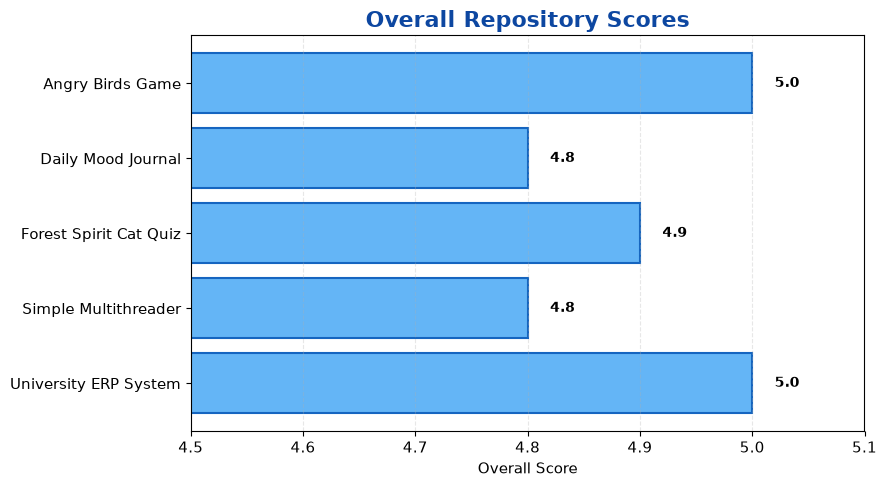

In [82]:
plt.figure(figsize=(9,5))

bars = plt.barh(
    df["Repository"],
    df["Overall"],
    color="#64B5F6",
    edgecolor="#1565C0",
    linewidth=1.5
)

plt.xlim(4.5, 5.1)

plt.xlabel("Overall Score")

plt.title(
    "Overall Repository Scores",
    fontsize=16,
    fontweight="bold",
    color="#0D47A1"
)

plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.02,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## ⏱️ Processing Time Analysis

The execution time required to analyze each repository is compared below. The proposed system consistently analyzes repositories within approximately one minute.

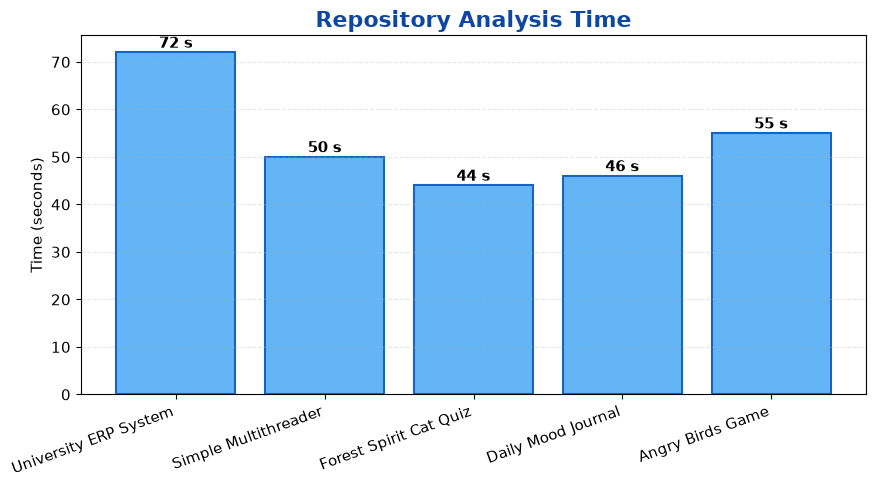

In [83]:
plt.figure(figsize=(9,5))

bars = plt.bar(
    df["Repository"],
    df["Time (s)"],
    color="#64B5F6",
    edgecolor="#1565C0",
    linewidth=1.5
)

plt.title(
    "Repository Analysis Time",
    fontsize=16,
    fontweight="bold",
    color="#0D47A1"
)

plt.ylabel("Time (seconds)")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(rotation=20, ha="right")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+1,
        f"{int(h)} s",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## 🍩 Overall Score Distribution

The distribution of overall repository evaluation scores is shown below.

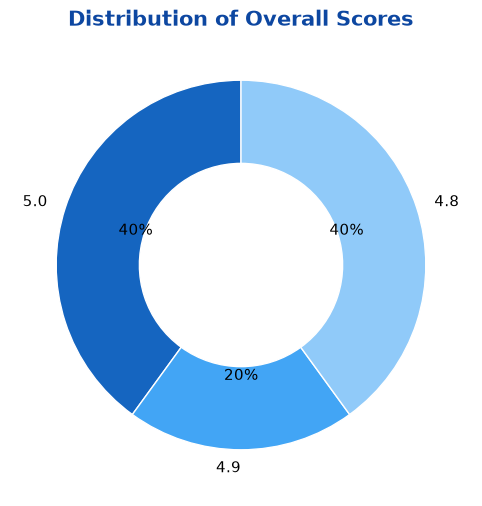

In [84]:
score_counts = df["Overall"].value_counts().sort_index(ascending=False)

colors = [
    "#1565C0",
    "#42A5F5",
    "#90CAF9"
]

plt.figure(figsize=(6,6))

plt.pie(
    score_counts,
    labels=score_counts.index,
    autopct="%1.0f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.45, edgecolor="white")
)

plt.title(
    "Distribution of Overall Scores",
    fontsize=15,
    fontweight="bold",
    color="#0D47A1"
)

plt.show()

## 📦 Performance Statistics

The following statistics summarize the overall performance of the proposed Repository Code Reviewer across all evaluated repositories.

In [85]:
from IPython.display import display, HTML

display(HTML(f"""
<div style="display:grid;
grid-template-columns:repeat(3,1fr);
gap:18px;
margin-top:20px;">

<div style="background:#F8FBFF;border:1px solid #D6E4F0;border-radius:12px;padding:18px;text-align:center;">
<h4 style="color:#1565C0;">Repositories</h4>
<h2>5</h2>
</div>

<div style="background:#F8FBFF;border:1px solid #D6E4F0;border-radius:12px;padding:18px;text-align:center;">
<h4 style="color:#1565C0;">Average Overall</h4>
<h2>{df["Overall"].mean():.2f}/5</h2>
</div>

<div style="background:#F8FBFF;border:1px solid #D6E4F0;border-radius:12px;padding:18px;text-align:center;">
<h4 style="color:#1565C0;">Highest Score</h4>
<h2>{df["Overall"].max():.1f}</h2>
</div>

<div style="background:#F8FBFF;border:1px solid #D6E4F0;border-radius:12px;padding:18px;text-align:center;">
<h4 style="color:#1565C0;">Lowest Score</h4>
<h2>{df["Overall"].min():.1f}</h2>
</div>

<div style="background:#F8FBFF;border:1px solid #D6E4F0;border-radius:12px;padding:18px;text-align:center;">
<h4 style="color:#1565C0;">Average Time</h4>
<h2>{df["Time (s)"].mean():.1f} s</h2>
</div>

<div style="background:#F8FBFF;border:1px solid #D6E4F0;border-radius:12px;padding:18px;text-align:center;">
<h4 style="color:#1565C0;">Fastest Analysis</h4>
<h2>{df["Time (s)"].min()} s</h2>
</div>

</div>
"""))

## 🔥 Repository Evaluation Heatmap

The heatmap below provides a visual comparison of evaluation scores across all repositories and evaluation criteria.

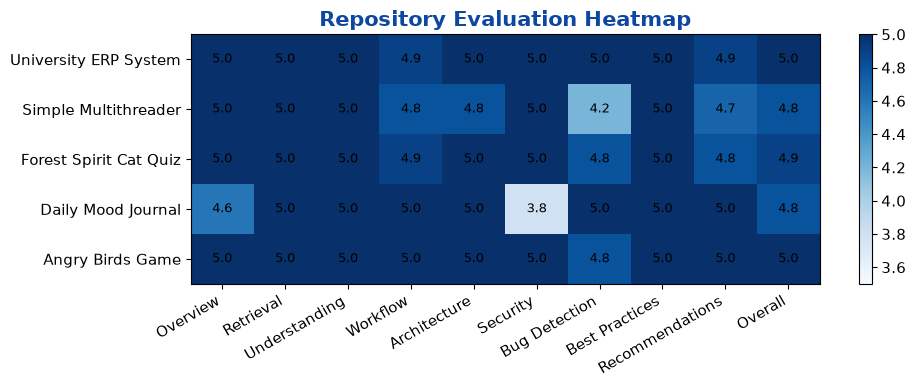

In [86]:
import matplotlib.pyplot as plt
import numpy as np

heatmap_data = df.drop(columns=["Repository", "Time (s)"]).values

fig, ax = plt.subplots(figsize=(10,4))

im = ax.imshow(
    heatmap_data,
    cmap="Blues",
    aspect="auto",
    vmin=3.5,
    vmax=5.0
)

ax.set_xticks(np.arange(len(df.columns)-2))
ax.set_xticklabels(df.columns[1:-1], rotation=30, ha="right")

ax.set_yticks(np.arange(len(df)))
ax.set_yticklabels(df["Repository"])

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(
            j,
            i,
            f"{heatmap_data[i,j]:.1f}",
            ha="center",
            va="center",
            color="black",
            fontsize=9
        )

plt.title(
    "Repository Evaluation Heatmap",
    fontsize=15,
    fontweight="bold",
    color="#0D47A1"
)

plt.colorbar(im)
plt.tight_layout()
plt.show()

## 📝 Overall Evaluation Summary

Across the five evaluated repositories, the proposed AI-powered Repository Code Reviewer consistently demonstrated high-quality repository understanding, semantic retrieval, architecture reconstruction, workflow analysis, security assessment, and engineering recommendations.

The system achieved an **average overall evaluation score of 4.90/5** while maintaining an **average analysis time of 53.4 seconds**. These results indicate that the proposed multi-agent Retrieval-Augmented Generation framework is effective for automated software repository comprehension and quality assessment.